<img align="center" src="https://iili.io/3wI8gI.png" style="height:90px" style="width:30px"/>

<h1><center>Canceled bookings at a hotel</center></h1>

<hr style="border:3px solid pink"> </hr>



You have been assigned the task of building a model that will predict whether or not a customer of a hotel will cancel their booking. The data for this assingment is found in the csv file `hotel_clf`

<br> 
<div>
<img src="https://5.imimg.com/data5/PC/BL/MY-33192851/hotel-reservation-services-500x500.jpg" width="400"/>
</div>
<br> 
If the model predicts that a customer will cancel their booking, that customer will be sent a special deal to try to keep the customer from cancel the booking. If the prediction is correct (a True Positive), the expected gain is 1000 SEK. However, if the prediction is wrong (a False Positive), the expected loss is 500 SEK. 

Your goal is to build the most profitable model possible.


<hr style="border:3px solid pink"> </hr>

Instructions for train test split:

- Test size = 0.2
- Random state = 42

In [1]:
# imports
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder


In [2]:
# load raw data
df = pd.read_csv("hotel_clf.csv")
df.head()

,hotel,is_canceled,lead_time,adults,children,market_segment,country,reserved_room_type,booking_changes,adr,customer_type
0,City Hotel,1,196,2,0.0,Online TA,ESP,A,0,105.3,Transient
1,City Hotel,0,44,2,0.0,Offline TA/TO,FRA,D,0,60.0,Transient
2,City Hotel,1,279,2,0.0,Groups,PRT,A,0,65.0,Transient
3,City Hotel,0,22,1,0.0,Corporate,PRT,A,0,62.0,Transient-Party
4,City Hotel,1,299,2,0.0,Groups,PRT,A,0,62.0,Transient-Party


In [3]:
# check cardinality of categorical columns
non_numerical = df.select_dtypes(exclude='number').columns.to_list()
for i in non_numerical:
    print(i,len(df[i].unique()))

hotel 2
market_segment 7
country 104
reserved_room_type 9
customer_type 4


In [4]:
# country has 104 categories - too high-cardinality to one-hot encode directly,
# so bucket it into continents instead. unmapped codes fall back to "Other"
import pycountry_convert as pc

def country_to_continent(code3):
    try:
        code2 = pc.country_alpha3_to_country_alpha2(code3)
        return pc.country_alpha2_to_continent_code(code2)
    except KeyError:
        return "Other"

df["continent"] = df["country"].apply(country_to_continent)
df.drop("country",axis=1,inplace=True)

In [5]:
# check: country replaced by continent
df.head()

,hotel,is_canceled,lead_time,adults,children,market_segment,reserved_room_type,booking_changes,adr,customer_type,continent
0,City Hotel,1,196,2,0.0,Online TA,A,0,105.3,Transient,EU
1,City Hotel,0,44,2,0.0,Offline TA/TO,D,0,60.0,Transient,EU
2,City Hotel,1,279,2,0.0,Groups,A,0,65.0,Transient,EU
3,City Hotel,0,22,1,0.0,Corporate,A,0,62.0,Transient-Party,EU
4,City Hotel,1,299,2,0.0,Groups,A,0,62.0,Transient-Party,EU


In [6]:
X = df.drop("is_canceled",axis = 1)
y = df["is_canceled"]

# split columns by dtype so each group gets its own preprocessing
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

# numeric: fill missing values with the mean, then scale
imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()
num_transformer = make_pipeline(imputer, scaler)

# categorical: one-hot encode. drop="if_binary" collapses 2-category columns
# crashes when a rare category (e.g. a continent) is missing from a CV fold
encoder = OneHotEncoder(drop="if_binary", handle_unknown="ignore")
cat_transformer = encoder

# combine both branches into one preprocessor
preprocessor = make_column_transformer(
    (num_transformer, num_features),
    (cat_transformer, cat_features)
)

In [7]:
# split into train/test per assignment instructions, then build the full pipeline
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
clf = LogisticRegression(max_iter=5000)
pipe = make_pipeline(preprocessor, clf)

# search a wide log-scaled range for C (inverse regularization strength)
param_grid = {
    "logisticregression__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]
}

/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as 

Precision: 0.7261652542372882
Recall: 0.469359808284834
Accuracy: 0.741625
F1: 0.5701809107922645
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.90      0.82      5079
           1       0.73      0.47      0.57      2921

    accuracy                           0.74      8000
   macro avg       0.74      0.68      0.69      8000
weighted avg       0.74      0.74      0.73      8000



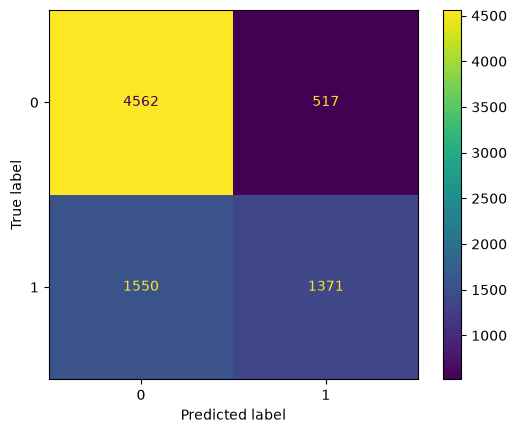

In [8]:
from sklearn.metrics import f1_score, classification_report, recall_score, accuracy_score, precision_score, ConfusionMatrixDisplay

# baseline model: pick the C that maximizes recall (catch as many cancellations as possible)
grid = GridSearchCV(pipe, param_grid, scoring='recall')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_train)

precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
accuracy = accuracy_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)
classification_rep = classification_report(y_train, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")
print(f"F1: {f1}")
print(f"Classification Report: {classification_rep}")

ConfusionMatrixDisplay.from_estimator(grid, X_train, y_train)

# BONUS CHALLENGE 1!

- Try out building your own scoring function that you pass to the scoring parameter in the GridSearchCV object!

*Check out scikit-learns `make_scorer()` method*

/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as 

Best score:219100.0
Best params: {'logisticregression__C': 3}
Precision: 0.7261652542372882
Recall: 0.469359808284834
Accuracy: 0.741625
F1: 0.5701809107922645
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.90      0.82      5079
           1       0.73      0.47      0.57      2921

    accuracy                           0.74      8000
   macro avg       0.74      0.68      0.69      8000
weighted avg       0.74      0.74      0.73      8000



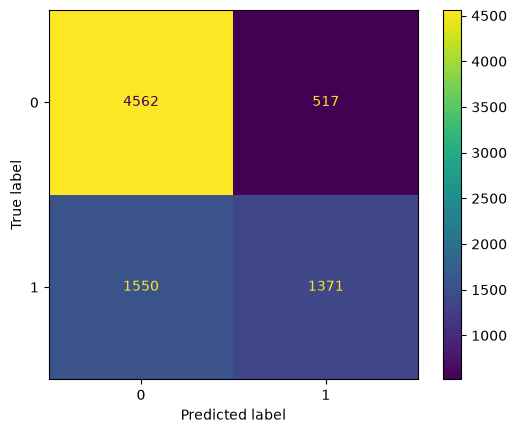

In [9]:
from sklearn.metrics import confusion_matrix, make_scorer

# custom scorer matching the assignment's actual payoff:
# +1000 SEK per correctly caught cancellation (TP), -500 SEK per false alarm (FP)
def profit_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return 1000 * tp - 500 * fp

profit_scorer = make_scorer(profit_score, greater_is_better=True)

# pick the C that maximizes profit instead of recall
grid_profit = GridSearchCV(pipe, param_grid, scoring=profit_scorer)
grid_profit.fit(X_train, y_train)

best_model_profit = grid_profit.best_estimator_
y_pred_profit = best_model_profit.predict(X_train)

precision_profit = precision_score(y_train, y_pred_profit)
recall_profit = recall_score(y_train, y_pred_profit)
accuracy_profit = accuracy_score(y_train, y_pred_profit)
f1_profit = f1_score(y_train, y_pred_profit)
classification_rep_profit = classification_report(y_train, y_pred_profit)

print(f"Best score:{grid_profit.best_score_}\nBest params: {grid_profit.best_params_}")
print(f"Precision: {precision_profit}")
print(f"Recall: {recall_profit}")
print(f"Accuracy: {accuracy_profit}")
print(f"F1: {f1_profit}")
print(f"Classification Report: {classification_rep_profit}")

ConfusionMatrixDisplay.from_estimator(grid_profit, X_train, y_train)

In [10]:
import numpy as np

# tuning C alone barely moves recall/precision here: at the default 0.5 threshold,
# more capacity (higher C) tends to help both recall AND profit together, so both
# GridSearchCVs above converge on the same C. The real lever for the recall vs.
# profit trade-off is the DECISION THRESHOLD, not C.
#
# sweep the threshold on best_model_profit's predicted probabilities and pick the
# one that actually maximizes profit on the training set
proba_train = best_model_profit.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
profits = [profit_score(y_train, (proba_train >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(profits)]
print(f"Best threshold for profit: {best_threshold:.2f} (train profit: {max(profits):,.0f})")

y_pred_profit_thresh = (proba_train >= best_threshold).astype(int)

precision_profit_thresh = precision_score(y_train, y_pred_profit_thresh)
recall_profit_thresh = recall_score(y_train, y_pred_profit_thresh)
accuracy_profit_thresh = accuracy_score(y_train, y_pred_profit_thresh)
f1_profit_thresh = f1_score(y_train, y_pred_profit_thresh)

print(f"Precision: {precision_profit_thresh}")
print(f"Recall: {recall_profit_thresh}")
print(f"Accuracy: {accuracy_profit_thresh}")
print(f"F1: {f1_profit_thresh}")


Best threshold for profit: 0.37 (train profit: 1,306,000)
Precision: 0.5907746895328209
Recall: 0.6840123245463883
Accuracy: 0.711625
F1: 0.6339838172298905


In [11]:
# compare train vs test performance for both models, to check for overfitting
# and see how each one actually performs on unseen data
def evaluate(model, X, y, threshold=None):
    # threshold=None uses the model's default predict() (0.5 cutoff);
    # a numeric threshold applies it to predict_proba instead, so the
    # profit-optimized model can use the threshold tuned for profit
    if threshold is None:
        y_pred = model.predict(X)
    else:
        y_pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)
    return {
        "profit": profit_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "accuracy": accuracy_score(y, y_pred),
        "f1": f1_score(y, y_pred),
    }

comparison = pd.DataFrame({
    "recall-optimized (train)": evaluate(best_model, X_train, y_train),
    "recall-optimized (test)": evaluate(best_model, X_test, y_test),
    "profit-optimized (train)": evaluate(best_model_profit, X_train, y_train, threshold=best_threshold),
    "profit-optimized (test)": evaluate(best_model_profit, X_test, y_test, threshold=best_threshold),
})

comparison

,recall-optimized (train),recall-optimized (test),profit-optimized (train),profit-optimized (test)
profit,1.112500e+06,294000.000000,1.306000e+06,337000.000000
precision,7.261653e-01,0.739130,5.907747e-01,0.597647
recall,4.693598e-01,0.469737,6.840123e-01,0.668421
accuracy,7.416250e-01,0.735500,7.116250e-01,0.703000
f1,5.701809e-01,0.574417,6.339838e-01,0.631056


# BONUS CHALLENGE 2!

- Instead of a LogReg model, use a RandomForestClassifier model!

Which model had the best performance? Was there a big difference?


In [12]:
from sklearn.ensemble import RandomForestClassifier
rfc2 = RandomForestClassifier()
pipe2 = make_pipeline(preprocessor, rfc2)
param_grid_rf = {
    "randomforestclassifier__n_estimators": [100, 200],
    "randomforestclassifier__max_depth": [5, 10, None],
    "randomforestclassifier__class_weight": ["balanced", None],
}
grid_rf = GridSearchCV(pipe2, param_grid_rf, scoring='recall')
grid_rf.fit(X_train, y_train)

/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__class_weight': ['balanced', None], 'randomforestclassifier__max_depth': [5, 10, ...], 'randomforestclassifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if N

In [13]:
best_model_rf = grid_rf.best_estimator_
print(grid_rf.best_params_)

{'randomforestclassifier__class_weight': 'balanced', 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 200}


In [14]:
comparison = pd.DataFrame({
    "recall-optimized (train)": evaluate(best_model, X_train, y_train),
    "recall-optimized (test)": evaluate(best_model, X_test, y_test),
    "profit-optimized (train)": evaluate(best_model_profit, X_train, y_train, threshold=best_threshold),
    "profit-optimized (test)": evaluate(best_model_profit, X_test, y_test, threshold=best_threshold),
    "rf-recall-opt  (train)":evaluate(best_model_rf, X_train, y_train,threshold=best_threshold),
    "rf-recall-opt  (test)":evaluate(best_model_rf, X_test, y_test,threshold=best_threshold),

})

In [15]:
pipe3 = make_pipeline(preprocessor, rfc2)
param_grid_rf = {
    "randomforestclassifier__n_estimators": [100, 200],
    "randomforestclassifier__max_depth": [5, 10, None],
    "randomforestclassifier__class_weight": ["balanced", None],
}
grid_rf = GridSearchCV(pipe3, param_grid_rf, scoring=profit_scorer)
grid_rf.fit(X_train, y_train)
best_model_rf_myscore = grid_rf.best_estimator_
print(grid_rf.best_params_)

/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/hugo/Documents/temp/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as 

{'randomforestclassifier__class_weight': 'balanced', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__n_estimators': 100}


In [16]:
comparison = pd.DataFrame({
    "recall-optimized (train)": evaluate(best_model, X_train, y_train),
    "recall-optimized (test)": evaluate(best_model, X_test, y_test),
    "profit-optimized (train)": evaluate(best_model_profit, X_train, y_train, threshold=best_threshold),
    "profit-optimized (test)": evaluate(best_model_profit, X_test, y_test, threshold=best_threshold),
    "rf-recall-opt  (train)":evaluate(best_model_rf, X_train, y_train),
    "rf-recall-opt  (test)":evaluate(best_model_rf, X_test, y_test),
    "rf-recall-opt-my-score  (train)":evaluate(best_model_rf_myscore, X_train, y_train, threshold=best_threshold),
    "rf-recall-opt-my-score  (test)":evaluate(best_model_rf_myscore,X_test, y_test, threshold=best_threshold),
})

In [17]:
comparison

,recall-optimized (train),recall-optimized (test),profit-optimized (train),profit-optimized (test),rf-recall-opt (train),rf-recall-opt (test),rf-recall-opt-my-score (train),rf-recall-opt-my-score (test)
profit,1.112500e+06,294000.000000,1.306000e+06,337000.000000,1.454000e+06,348000.000000,1.636000e+06,384500.000000
precision,7.261653e-01,0.739130,5.907747e-01,0.597647,5.910662e-01,0.578059,5.498214e-01,0.536934
recall,4.693598e-01,0.469737,6.840123e-01,0.668421,7.610407e-01,0.721053,9.483054e-01,0.889474
accuracy,7.416250e-01,0.735500,7.116250e-01,0.703000,7.205000e-01,0.694000,6.976250e-01,0.666500
f1,5.701809e-01,0.574417,6.339838e-01,0.631056,6.653696e-01,0.641686,6.960673e-01,0.669638
